In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read in data for processing
with open('config.json', 'r') as f:
        config = json.load(f)

mcmc_settings = config.get("mcmc_settings", {})

# output_settings = config.get("output_settings", {})
# output_directory = output_settings.get("output_directory", "results/")
# # create output directories if they do not exist
# if not os.path.exists(output_directory):
#     os.makedirs(output_directory)
# figures_directory = output_settings.get("figures_directory", os.path.join(output_directory, "figures/"))
# if not os.path.exists(figures_directory):
#     os.makedirs(figures_directory)
# data_directory = output_settings.get("data_directory", os.path.join(output_directory, "data/"))
# if not os.path.exists(data_directory):
#     os.makedirs(data_directory)
# figures_to_generate = output_settings.get("figures", {})

input_settings = config.get("input_settings", {})
file_delimiter = input_settings.get("file_delimiter", ",")

debug_settings = config.get("debug_settings", {})
enable_debug = debug_settings.get("enable_debug", False)

# Create a DataFrame to store model data
# The DataFrame can have any number of rows and any number of columns
# The columns will be identified by header names x_{label}, theta_{label}, y_{label}, etc.
# x will be read from modelData/appDomain.txt
# theta will be read from modelData/thetaVals.txt
# y will be read from modelData/modelPredictions.txt
# Each row will correspond to a different model run

model_data = pd.DataFrame()

#populate x values from appDomain.txt
# The first line of appDomain.txt contains the header names
# The subsequent lines contain the x values
with open('modelData/appDomain.txt', 'r') as f:
    lines = [line.strip() for line in f if line.strip()]
    headers = lines[0].strip().split(file_delimiter)
    for i, header in enumerate(headers):
        col_name = f'x_{header}'
        model_data[col_name] = [float(line.strip().split(file_delimiter)[i]) for line in lines[1:]]

# #populate theta values from thetaVals.txt
# The first line of thetaVals.txt contains the header names
# The subsequent lines contain the theta values
with open('modelData/thetaVals.txt', 'r') as f:
    lines = [line.strip() for line in f if line.strip()]
    headers = lines[0].strip().split(file_delimiter)
    for i, header in enumerate(headers):
        col_name = f'theta_{header}'
        model_data[col_name] = [float(line.strip().split(file_delimiter)[i]) for line in lines[1:]]

#populate y values from modelPredictions.txt
# The first line of modelPredictions.txt contains the header names
# The subsequent lines contain the y values
# If there are blank lines at the end of the file, ignore
with open('modelData/modelPredictions.txt', 'r') as f:
    lines = [line.strip() for line in f if line.strip()]
    headers = lines[0].strip().split(file_delimiter)
    for i, header in enumerate(headers):
        col_name = f'y_{header}'
        model_data[col_name] = [float(line.strip().split(file_delimiter)[i]) for line in lines[1:]]


# Create a dataframe to store the observation data
# The DataFrame can have any number of rows and any number of columns
# The columns will be identified by header names x_{label}, y_{label}, etc.
# x will be read from obsData/appDomain.txt
# y will be read from obsData/observationData.txt
# Each row will correspond to a different observation
obs_data = pd.DataFrame()
with open('observationData/appDomain.txt', 'r') as f:
    lines = [line.strip() for line in f if line.strip()]
    headers = lines[0].strip().split(file_delimiter)
    for i, header in enumerate(headers):
        col_name = f'x_{header}'
        obs_data[col_name] = [float(line.strip().split(file_delimiter)[i]) for line in lines[1:]]

with open('observationData/observationData.txt', 'r') as f:
    lines = [line.strip() for line in f if line.strip()]
    headers = lines[0].strip().split(file_delimiter)
    for i, header in enumerate(headers):
        col_name = f'xi_{header}'
        obs_data[col_name] = [float(line.strip().split(file_delimiter)[i]) for line in lines[1:]]


model_domain = model_data[[col for col in model_data.columns if col.startswith('x_')]]
calib_params = model_data[[col for col in model_data.columns if col.startswith('theta_')]]

theta_labels = [col.replace('theta_', '') for col in calib_params.columns]
app_labels = [col.replace('x_', '') for col in model_domain.columns]


# Print the dataframes for debugging
print("Model Data:")
print(model_data.head())
print("\nObservation Data:")
print(obs_data.head())

Model Data:
   x_dipoleSeparation_DDD  theta_coreSize      theta_mu  theta_nu  y_crss_DDD
0               25.311394        1.508177  6.261392e+10  0.315867        75.0
1               22.045408        2.220765  5.273994e+10  0.330880        85.0
2               22.045408        1.909357  5.980446e+10  0.312178        95.0
3               22.861904        2.500962  5.696179e+10  0.307269        80.0
4               26.127891        0.996042  5.723887e+10  0.328893        75.0

Observation Data:
   x_dipoleSeparation_MD  xi_crss_MD
0               5.477308       244.0
1              10.563380       166.0
2              17.996870       118.0
3              21.909233        86.0
4              27.816901        56.0


In [2]:
# create standardized/normalized dataframes
model_normalized = model_data.copy()
observation_normalized = obs_data.copy()

# transform the simulator inputs (x,theta) to the unit hypercube [0,1] using min-max scaling
for col in model_data.columns:
    if col.startswith('x_') or col.startswith('theta_'):
        min_val = model_data[col].min()
        max_val = model_data[col].max()
        model_normalized[col] = (model_data[col] - min_val) / (max_val - min_val) 

# transform the simulator outputs to be zero mean and unit variance
for col in model_data.columns:
    if col.startswith('y_'):
        mean_val = model_data[col].mean()
        std_val = model_data[col].std()
        model_normalized[col] = (model_data[col] - mean_val) / std_val
        
# repeat the procedure for the observation data
for col in obs_data.columns:
    if col.startswith('x_'):
        min_val = obs_data[col].min()
        max_val = obs_data[col].max()
        observation_normalized[col] = (obs_data[col] - min_val) / (max_val - min_val)
        
for col in obs_data.columns:
    if col.startswith('xi_'):
        mean_val = obs_data[col].mean()
        std_val = obs_data[col].std()
        observation_normalized[col] = (obs_data[col] - mean_val) / std_val
        
#print normalized dataframes for debugging

print("\nNormalized Model Data:")
print(model_normalized.head())
print("\nNormalized Observation Data:")
print(observation_normalized.head())
    



Normalized Model Data:
   x_dipoleSeparation_DDD  theta_coreSize  theta_mu  theta_nu  y_crss_DDD
0                0.962963        0.393002  0.962924  0.309481   -0.769574
1                0.814815        0.689197  0.311185  0.764079   -0.718309
2                0.814815        0.559757  0.777483  0.197777   -0.667044
3                0.851852        0.805665  0.589851  0.049143   -0.743942
4                1.000000        0.180127  0.608140  0.703910   -0.769574

Normalized Observation Data:
   x_dipoleSeparation_MD  xi_crss_MD
0               0.000000    1.491123
1               0.227671    0.433781
2               0.560420   -0.216891
3               0.735552   -0.650672
4               1.000000   -1.057342


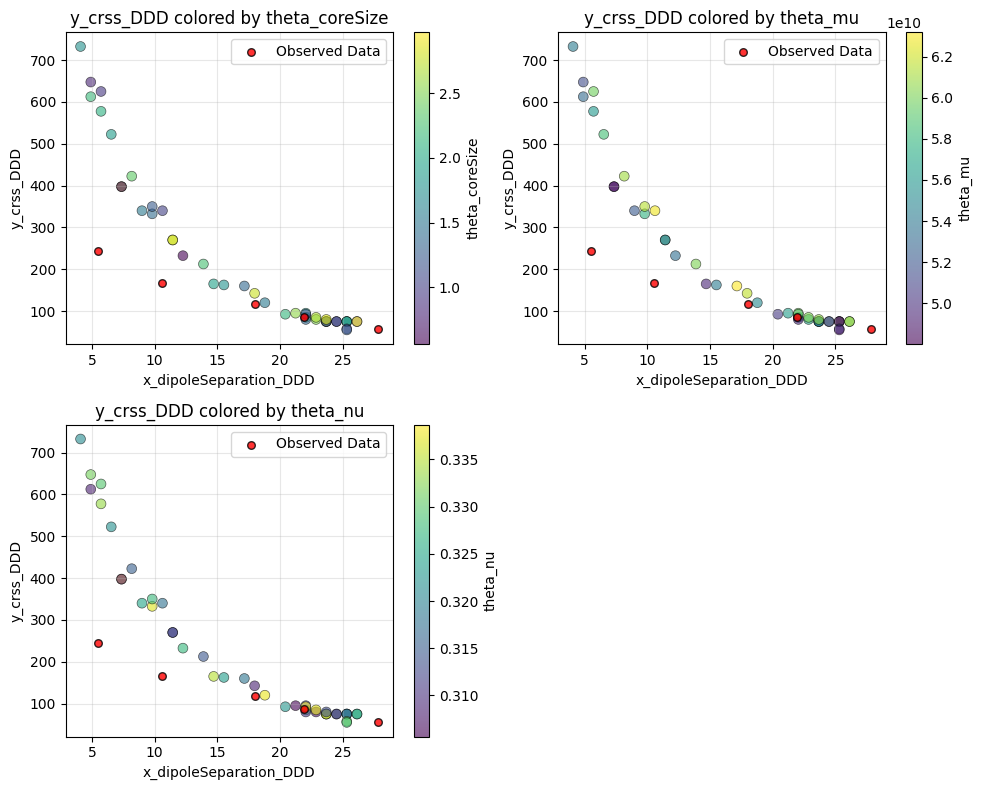

In [3]:
def generate_rawData_figure(model_data, obs_data, figures_directory):
    """
    Create subplots for each theta parameter showing:
    - X-axis: application domain (x values)
    - Y-axis: calibration metric (y values)
    - Point color: theta parameter value
    - Observed data points
    """
    
    model_x_columns = [col for col in model_data.columns if col.startswith('x_')]
    model_y_columns = [col for col in model_data.columns if col.startswith('y_')]
    observation_x_columns = [col for col in obs_data.columns if col.startswith('x_')] if obs_data is not None else []
    observation_y_columns = [col for col in obs_data.columns if col.startswith('xi_')] if obs_data is not None else []
    
    theta_columns = [col for col in model_data.columns if col.startswith('theta_')]
    
    if not model_x_columns or not model_y_columns or not theta_columns:
        print("Missing required columns (x_, y_, or theta_)")
        return
    
    # Use first y column as calibration metric
    y_col = model_y_columns[0]
    x_col = model_x_columns[0]
    
    # Create subplot grid for theta parameters
    n_theta = len(theta_columns)
    n_cols = int(np.ceil(np.sqrt(n_theta)))
    n_rows = int(np.ceil(n_theta / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = np.atleast_1d(axes).flatten()
    
    for idx, theta_col in enumerate(theta_columns):
        ax = axes[idx]
        
        # Scatter plot colored by theta parameter value
        scatter = ax.scatter(model_data[x_col], model_data[y_col], 
                            c=model_data[theta_col], cmap='viridis', 
                            alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
        
        # Plot observed data
        if obs_data is not None and observation_y_columns and observation_y_columns[0] in obs_data.columns and observation_x_columns and observation_x_columns[0] in obs_data.columns:
            ax.scatter(obs_data[observation_x_columns[0]], obs_data[observation_y_columns[0]], color='red', label='Observed Data', alpha=0.8, s=30, edgecolors='black')
        
        ax.set_xlabel(f'{x_col}')
        ax.set_ylabel(f'{y_col}')
        ax.set_title(f'{y_col} colored by {theta_col}')
        ax.grid(True, alpha=0.3)
        ax.legend()
        
        # Add colorbar for each subplot
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label(theta_col)
    
    # Hide unused subplots
    for idx in range(n_theta, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    # plt_path = os.path.join(figures_directory, f'rawData_theta_parameters.png')
    # # plt.savefig(plt_path, dpi=150)
    # # print(f'Saved raw data figure to {plt_path}')
    # plt.close()
    plt.show()

generate_rawData_figure(model_data, obs_data, figures_directory=None)

**Procedural Outline**

*Step 1:*
- Sample the latent calibration field $\delta(x)$
- Use metropolis-hastings step because the conditional density of $\delta(x)$ is not Gaussian because $\eta(x,\theta+\delta(x))$ is nonlinear in $\delta(x)$
- MH sample based upon
    - GP hyperparameters of $\delta(x)$
    - Emulator hyperparameters 
    - Observed data

*Step 2:*
- Sample GP hyperparameters for $\delta(x)$

*Step 3:*
- Sample noise variance (Gibbs)

**All GP priors:**
- $\beta_V:=$ discrepancy response basis scaling vector
- $\lambda_{Vz}:=$ marginal discrepancy precision (possibility of groups)
- $\beta_U:=$ simulation response basis scaling vectors
- $\lambda_{Uz}:=$ marginal simulation precision
- $\lambda_{Ws}:=$ simulation data precision
- $\lambda_{WOs}:=$ simulation noise precision
- $\lambda_{Os}:=$ observed data noise precision


In [4]:
def rbf_kernel(X, Y, ell=1.0, var=1.0):
    X = np.atleast_2d(X)
    Y = np.atleast_2d(Y)
    sqdist = np.sum((X[:, None, :] - Y[None, :, :])**2, axis=2)
    return var * np.exp(-0.5 * sqdist / ell**2)

In [5]:
def log_likelihood(y, x, theta, delta, eta, sigma2):
    """
    y_i ~ N( eta(x_i, theta + delta(x_i)), sigma2 )
    """
    y_pred = np.zeros_like(y)

    for i in range(len(x)):
        theta_star = theta + delta[:, i]
        y_pred[i] = eta(x[i], theta_star)

    resid = y - y_pred
    return -0.5 * (
        np.sum(resid**2) / sigma2
        + len(y) * np.log(2 * np.pi * sigma2)
    )

In [6]:
def log_prior_delta(delta_k, K_delta_inv):
    return -0.5 * delta_k.T @ K_delta_inv @ delta_k

In [7]:
from scipy.linalg import cholesky, cho_solve
def mh_update_delta_k(
    k, delta, theta, ell_k, var_k,
    x_md, y_md, eta, sigma2,
    mh_scale
):
    No = x_md.shape[0]

    K = rbf_kernel(x_md, x_md, ell=ell_k, var=var_k)
    L = cholesky(K + 1e-8*np.eye(No), lower=True)

    proposal = delta[k] + mh_scale * (L @ np.random.randn(No))

    delta_prop = delta.copy()
    delta_prop[k] = proposal

    logpost_curr = (
        log_likelihood(y_md, x_md, theta, delta, eta, sigma2)
        + log_prior_delta(delta[k], np.linalg.inv(K))
    )

    logpost_prop = (
        log_likelihood(y_md, x_md, theta, delta_prop, eta, sigma2)
        + log_prior_delta(proposal, np.linalg.inv(K))
    )

    log_alpha = logpost_prop - logpost_curr

    if np.log(np.random.rand()) < log_alpha:
        delta[k] = proposal
        accepted = True
    else:
        accepted = False

    return delta, accepted


In [8]:
def log_prior_hyperparams(ell, var, prior_ell, prior_var):
    """
    Log-prior for kernel hyperparameters (ell, var).

    prior_ell = {"mu": ..., "sigma": ...} on log(ell)
    prior_var = {"mu": ..., "sigma": ...} on log(var)
    """

    log_ell = np.log(ell)
    log_var = np.log(var)

    lp_ell = norm.logpdf(
        log_ell,
        loc=prior_ell["mu"],
        scale=prior_ell["sigma"]
    )

    lp_var = norm.logpdf(
        log_var,
        loc=prior_var["mu"],
        scale=prior_var["sigma"]
    )

    return lp_ell + lp_var



In [9]:
def gp_log_density(delta_k, K):
    """
    Stable log N(0,K) evaluation.
    """
    No = len(delta_k)
    L = np.linalg.cholesky(K)

    alpha = np.linalg.solve(L.T, np.linalg.solve(L, delta_k))

    logdet = 2*np.sum(np.log(np.diag(L)))

    return -0.5 * (delta_k @ alpha + logdet + No*np.log(2*np.pi))


In [10]:
from scipy.stats import multivariate_normal

def mh_update_delta_hyperparams(
    delta_k, ell, var, x_md,
    prior_ell, prior_var,
    mh_scales
):
    log_ell_prop = np.log(ell) + mh_scales["log_ell_delta"] * np.random.randn()
    log_var_prop = np.log(var) + mh_scales["log_var_delta"] * np.random.randn()

    ell_prop = np.exp(log_ell_prop)
    var_prop = np.exp(log_var_prop)

    K_curr = rbf_kernel(x_md, x_md, ell=ell, var=var)+ 1e-8*np.eye(len(x_md))
    K_prop = rbf_kernel(x_md, x_md, ell=ell_prop, var=var_prop) + 1e-8*np.eye(len(x_md))

    logp_curr = (
        multivariate_normal.logpdf(delta_k, mean=np.zeros(len(delta_k)), cov=K_curr)
        + log_prior_hyperparams(ell, var, prior_ell, prior_var)
    )

    logp_prop = (
        multivariate_normal.logpdf(delta_k, mean=np.zeros(len(delta_k)), cov=K_prop)
        + log_prior_hyperparams(ell_prop, var_prop, prior_ell, prior_var)
    )

    if np.log(np.random.rand()) < (logp_prop - logp_curr):
        return ell_prop, var_prop, True
    else:
        return ell, var, False


In [11]:
def gibbs_sigma2(y, x, theta, delta, eta, a, b):
    resid = np.zeros_like(y)
    for i in range(len(x)):
        resid[i] = y[i] - eta(x[i], theta + delta[:, i])

    a_post = a + len(y) / 2
    b_post = b + 0.5 * np.sum(resid**2)

    return invgamma.rvs(a_post, scale=b_post)


In [12]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import numpy as np

# Simulator inputs
x_sim = model_normalized["x_dipoleSeparation_DDD"].values.reshape(-1,1)

theta_sim = model_normalized[[
    "theta_coreSize",
    "theta_mu",
    "theta_nu"
]].values

# Joint emulator input z = (x, theta)
Z_sim = np.hstack([x_sim, theta_sim])

# Simulator outputs
y_sim = model_normalized["y_crss_DDD"].values


d = Z_sim.shape[1]  # dimension = 1 + dtheta

kernel_eta = C(1.0, (1e-2, 1e2)) * RBF(
    length_scale=np.ones(d),
    length_scale_bounds=(1e-2, 1e2)
)

gp_eta = GaussianProcessRegressor(
    kernel=kernel_eta,
    alpha=1e-6,           # nugget for stability
    normalize_y=True,
    n_restarts_optimizer=5
)

gp_eta.fit(Z_sim, y_sim)

print("Trained emulator kernel:")
print(gp_eta.kernel_)



Trained emulator kernel:
1.08**2 * RBF(length_scale=[0.185, 8.89, 2.1, 1.56])


In [13]:
def eta_predict(x, theta_star, gp):
    """
    Predict emulator mean and variance at z=(x,theta_star)
    """
    z = np.hstack([x.reshape(1,-1), theta_star.reshape(1,-1)])
    
    mean, std = gp.predict(z, return_std=True)

    return mean.item(), (std.item()**2)


In [14]:
def log_likelihood_embedded(y_obs, x_obs, theta, delta, gp_eta, sigma2):
    """
    y_i ~ N( m_i , sigma2 + s_i^2 )
    where emulator provides (m_i, s_i^2)
    """
    N = len(y_obs)
    loglike = 0.0

    for i in range(N):

        theta_star = theta + delta[:, i]

        m_i, s2_i = eta_predict(
            x_obs[i],
            theta_star,
            gp_eta
        )

        total_var = sigma2 + s2_i

        resid = y_obs[i] - m_i

        loglike += -0.5 * (
            np.log(2*np.pi*total_var)
            + resid**2 / total_var
        )

    return loglike


In [15]:
def mh_update_delta_k(
    k, delta, theta,
    ell_k, var_k,
    x_obs, y_obs,
    gp_eta,
    sigma2,
    mh_scale
):
    No = len(x_obs)

    # --- GP prior covariance ---
    K = rbf_kernel(x_obs, x_obs, ell=ell_k, var=var_k) + 1e-8*np.eye(No)
    L = np.linalg.cholesky(K)

    # --- proposal ---
    proposal = delta[k] + mh_scale * (L @ np.random.randn(No))

    delta_prop = delta.copy()
    delta_prop[k] = proposal

    # --- log posterior current ---
    logpost_curr = (
        log_likelihood_embedded(y_obs, x_obs, theta, delta, gp_eta, sigma2)
        + gp_log_density(delta[k], K)
    )

    # --- log posterior proposed ---
    logpost_prop = (
        log_likelihood_embedded(y_obs, x_obs, theta, delta_prop, gp_eta, sigma2)
        + gp_log_density(proposal, K)
    )

    # print("mean proposal jump:", np.linalg.norm(delta_prop - delta))

    log_alpha = logpost_prop - logpost_curr

    # print(f"log posterior current: {logpost_curr:.3f}, proposed: {logpost_prop:.3f}, log alpha: {log_alpha:.3f}")

    if np.log(np.random.rand()) < log_alpha:
        delta[k] = proposal
        return delta, True
    else:
        return delta, False


In [16]:
from scipy.stats import invgamma

def gibbs_sigma2(y_obs, x_obs, theta, delta, gp_eta, a, b):

    resid = np.zeros_like(y_obs)

    for i in range(len(y_obs)):
        theta_star = theta + delta[:, i]
        m_i, _ = eta_predict(x_obs[i], theta_star, gp_eta)
        resid[i] = y_obs[i] - m_i

    a_post = a + len(y_obs)/2
    b_post = b + 0.5*np.sum(resid**2)

    return invgamma.rvs(a_post, scale=b_post)


In [17]:
def plot_delta_acceptance_trajectory(accept_trace, window=50):
    """
    Plot acceptance-rate trajectories for each discrepancy GP delta_k.

    Parameters
    ----------
    accept_trace : list of lists
        accept_trace[k][t] = 1 if delta_k accepted at iteration t, else 0

    window : int
        Rolling window size for smoothing acceptance rates

    Output
    ------
    Displays a trajectory plot of rolling acceptance rates.
    """

    n_delta = len(accept_trace)

    plt.figure(figsize=(10, 6))

    for k in range(n_delta):
        accepts = np.array(accept_trace[k])

        # Rolling acceptance rate
        rolling = np.convolve(
            accepts,
            np.ones(window) / window,
            mode="valid"
        )

        plt.plot(
            rolling,
            label=f"delta[{k}]"
        )

    plt.axhline(0.25, linestyle="--", label="Target ~0.25")
    plt.axhline(0.50, linestyle="--", label="Target ~0.50")

    plt.xlabel("Iteration")
    plt.ylabel(f"Rolling Acceptance Rate (window={window})")
    plt.title("Delta GP Acceptance Rate Trajectories")
    plt.legend()
    plt.grid(True)
    plt.show()


In [18]:

def plot_delta_jump_sizes(delta_chain):
    """
    Plot jump magnitudes ||delta^(t) - delta^(t-1)|| for each delta_k.

    Parameters
    ----------
    delta_chain : array
        Shape (Nmcmc, dtheta, n_obs)
        Stored delta latent fields across iterations.

    Output
    ------
    Line plot of jump norms for each discrepancy GP.
    """

    Nmcmc, dtheta, n_obs = delta_chain.shape

    plt.figure(figsize=(10, 6))

    for k in range(dtheta):

        # difference between successive iterations
        diffs = delta_chain[1:, k, :] - delta_chain[:-1, k, :]

        # norm of each jump
        jump_norms = np.linalg.norm(diffs, axis=1)

        plt.plot(jump_norms, label=f"delta[{k}] jump size")

    plt.xlabel("Iteration")
    plt.ylabel(r"$\|\delta^{(t)} - \delta^{(t-1)}\|$")
    plt.title("Delta GP Jump Magnitudes (Mixing Diagnostic)")
    plt.legend()
    plt.grid(True)
    plt.show()


Simulator design shape: (43, 1) (43, 3)
Observation shape: (5, 1) (5,)


/home/liammyhill/gitLocal/lmyhill/customCalibration/python_integratedDelta_custom/custom_python/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(



Trained emulator kernel:
1.03**2 * RBF(length_scale=[0.158, 100, 1.29, 1.85])

Fixed theta used:
[0.49159687 0.5014051  0.51913409]

Running embedded δ-MH sampler...

[ADAPT] Iter 50: mean accept = 0.613
[ADAPT] Updated mh_scale_delta = 0.5066
Iter 50/2000
 sigma2 = 0.49422638037140365
 delta acceptance rates: [0.58 0.64 0.62]
 ell_delta: [0.28798918 0.27994355 0.39660302]
 var_delta: [0.10548199 0.03818764 0.06897548]
--------------------------------------------------
[ADAPT] Iter 100: mean accept = 0.647
[ADAPT] Updated mh_scale_delta = 0.5142
Iter 100/2000
 sigma2 = 0.5206560895282822
 delta acceptance rates: [0.65 0.63 0.66]
 ell_delta: [0.13573788 0.21949144 0.64302617]
 var_delta: [0.07459525 0.06749035 0.17127716]
--------------------------------------------------
[ADAPT] Iter 150: mean accept = 0.633
[ADAPT] Updated mh_scale_delta = 0.5215
Iter 150/2000
 sigma2 = 0.4717576146119325
 delta acceptance rates: [0.60666667 0.62666667 0.66666667]
 ell_delta: [0.1119281  0.39052978 0

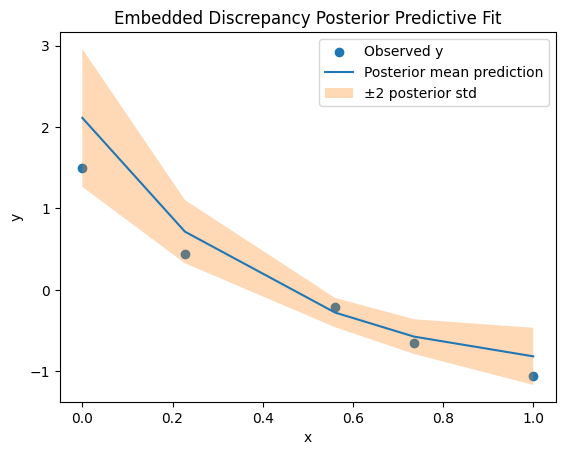

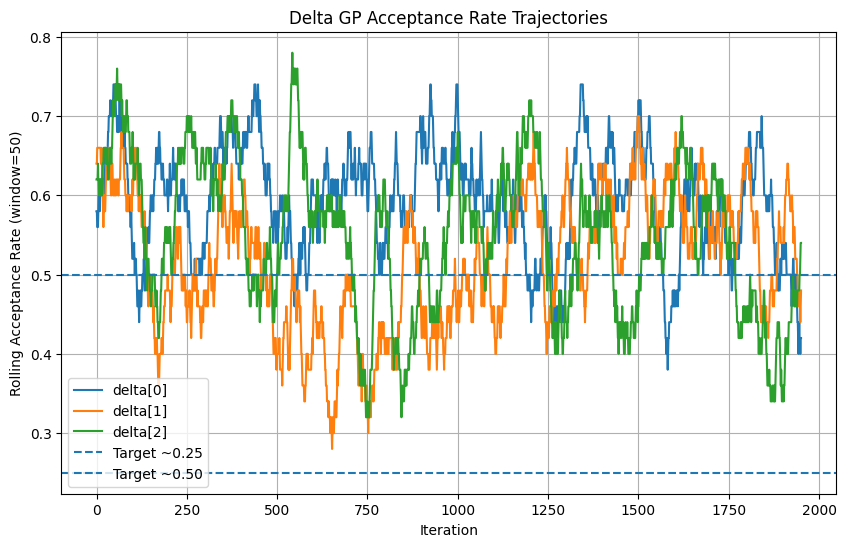

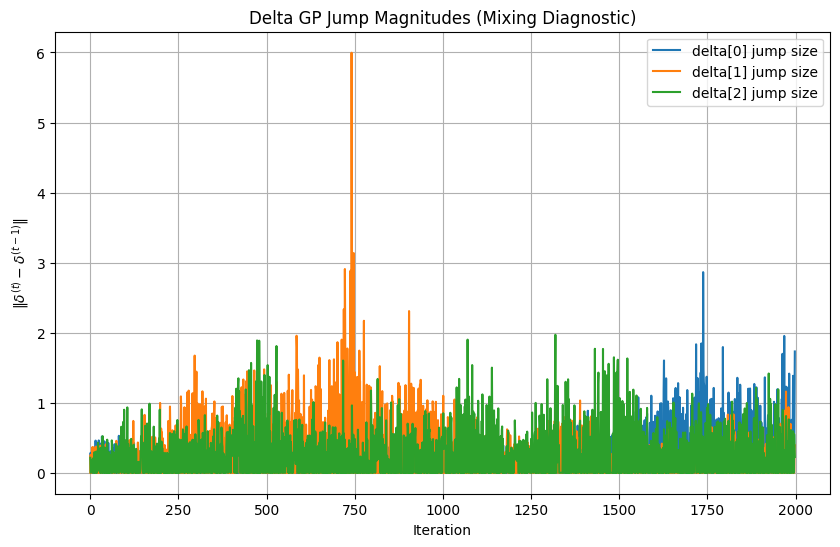

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


# ============================================================
# 1. Extract normalized arrays from your DataFrames
# ============================================================

# ---- simulator dataframe ----
x_sim = model_normalized["x_dipoleSeparation_DDD"].values.reshape(-1, 1)

theta_sim = model_normalized[[
    "theta_coreSize",
    "theta_mu",
    "theta_nu"
]].values

y_sim = model_normalized["y_crss_DDD"].values


# ---- observation dataframe ----
x_obs = observation_normalized["x_dipoleSeparation_MD"].values.reshape(-1, 1)
y_obs = observation_normalized["xi_crss_MD"].values


print("Simulator design shape:", x_sim.shape, theta_sim.shape)
print("Observation shape:", x_obs.shape, y_obs.shape)

dtheta = theta_sim.shape[1]
No = len(x_obs)

# ============================================================
# 2. Train probabilistic emulator GP η(x,θ)
# ============================================================

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

Z_sim = np.hstack([x_sim, theta_sim])

kernel_eta = C(1.0, (1e-2, 1e2)) * RBF(
    length_scale=np.ones(Z_sim.shape[1]),
    length_scale_bounds=(1e-2, 1e2)
)

gp_eta = GaussianProcessRegressor(
    kernel=kernel_eta,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=5
)

gp_eta.fit(Z_sim, y_sim)

print("\nTrained emulator kernel:")
print(gp_eta.kernel_)


# ============================================================
# 3. Initialize θ (fixed plug-in estimate)
# ============================================================

theta_fixed = theta_sim.mean(axis=0)

print("\nFixed theta used:")
print(theta_fixed)


# ============================================================
# 4. Initialize discrepancy δₖ(x) latent vectors
# ============================================================

delta = np.zeros((dtheta, No))

# Initial hyperparameters for each δₖ
ell_delta = 0.3 * np.ones(dtheta)
var_delta = 0.05 * np.ones(dtheta)

# Initial noise variance
sigma2 = 0.02**2


# ============================================================
# 5. Sampler config
# ============================================================

Nmcmc = 2000
mh_scale_delta = 0.5

prior_ell = {"mu": -1.0, "sigma": 1.0}
prior_var = {"mu": -2.0, "sigma": 1.0}

mh_scales = {
    "log_ell_delta": 0.1,
    "log_var_delta": 0.1
}

a_sigma = 2.0
b_sigma = 0.5


# Storage
delta_chain = np.zeros((Nmcmc, dtheta, No))
sigma2_chain = np.zeros(Nmcmc)

accept_delta = np.zeros(dtheta)

# --- acceptance trace storage ---
accept_trace = [[] for _ in range(dtheta)]

# --- MH scaling adaptation settings ---
burnin = 500
adapt_interval = 50
target_accept = 0.35

mh_scale_delta = 0.5  # initial guess

# store scale history (optional)
mh_scale_trace = []



# ============================================================
# 6. Run Embedded Discrepancy Sampler
# ============================================================

print("\nRunning embedded δ-MH sampler...\n")

for it in range(Nmcmc):

    # ---- update δₖ fields ----
    for k in range(dtheta):
        delta, acc = mh_update_delta_k(
            k,
            delta,
            theta_fixed,
            ell_delta[k],
            var_delta[k],
            x_obs,
            y_obs,
            gp_eta,
            sigma2,
            mh_scale_delta
        )
        accept_delta[k] += acc
        accept_trace[k].append(acc)
        
    # ---- adapt mh_scale_delta during burn-in ----
    if it < burnin and (it + 1) % adapt_interval == 0:

        # acceptance rate over last adapt_interval steps
        recent_accept = accept_delta / (it + 1)

        # average across delta dimensions
        mean_accept = np.mean(recent_accept)

        # log-scale update (stable + standard)
        gamma = 0.05  # adaptation speed

        mh_scale_delta *= np.exp(gamma * (mean_accept - target_accept))

        print(f"[ADAPT] Iter {it+1}: mean accept = {mean_accept:.3f}")
        print(f"[ADAPT] Updated mh_scale_delta = {mh_scale_delta:.4f}")


    # ---- update δ hyperparameters ----
    for k in range(dtheta):
        ell_delta[k], var_delta[k], _ = mh_update_delta_hyperparams(
            delta[k],
            ell_delta[k],
            var_delta[k],
            x_obs,
            prior_ell,
            prior_var,
            mh_scales
        )

    # ---- Gibbs update σ² ----
    sigma2 = gibbs_sigma2(
        y_obs,
        x_obs,
        theta_fixed,
        delta,
        gp_eta,
        a_sigma,
        b_sigma
    )

    # ---- store ----
    delta_chain[it] = delta
    sigma2_chain[it] = sigma2

    # ---- diagnostics ----
    if (it+1) % 50 == 0:
        print(f"Iter {it+1}/{Nmcmc}")
        print(" sigma2 =", sigma2)
        print(" delta acceptance rates:",
              accept_delta / (it+1))
        print(" ell_delta:", ell_delta)
        print(" var_delta:", var_delta)

        print("--------------------------------------------------")


print("\nSampler complete.")


# ============================================================
# 7. Posterior Predictive Check
# ============================================================

print("\nBuilding posterior predictive mean + uncertainty...\n")

y_post_mean = np.zeros(No)
y_post_var  = np.zeros(No)

Nsamp = 200
idx = np.random.choice(Nmcmc, Nsamp, replace=False)

for i in range(No):

    preds = []

    for s in idx:

        delta_s = delta_chain[s, :, i]
        theta_star = theta_fixed + delta_s

        m_i, s2_i = eta_predict(x_obs[i], theta_star, gp_eta)

        preds.append(m_i)

    preds = np.array(preds)
    

    y_post_mean[i] = preds.mean()
    y_post_var[i]  = preds.var()
    # print prediction mean and 95% credible interval
    print(f"x_obs[{i}] = {x_obs[i,0]:.3f}, y_obs = {y_obs[i]:.3f}, post pred mean = {y_post_mean[i]:.3f}, 95% CI = [{y_post_mean[i] - 2*np.sqrt(y_post_var[i]):.3f}, {y_post_mean[i] + 2*np.sqrt(y_post_var[i]):.3f}]")


# ============================================================
# 8. Plot Posterior Predictive Fit
# ============================================================

plt.figure()
plt.scatter(x_obs, y_obs, label="Observed y", marker="o")

plt.plot(x_obs, y_post_mean, label="Posterior mean prediction")

plt.fill_between(
    x_obs.ravel(),
    y_post_mean - 2*np.sqrt(y_post_var),
    y_post_mean + 2*np.sqrt(y_post_var),
    alpha=0.3,
    label="±2 posterior std"
)

plt.title("Embedded Discrepancy Posterior Predictive Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

plot_delta_acceptance_trajectory(accept_trace, window=50)
plot_delta_jump_sizes(delta_chain)


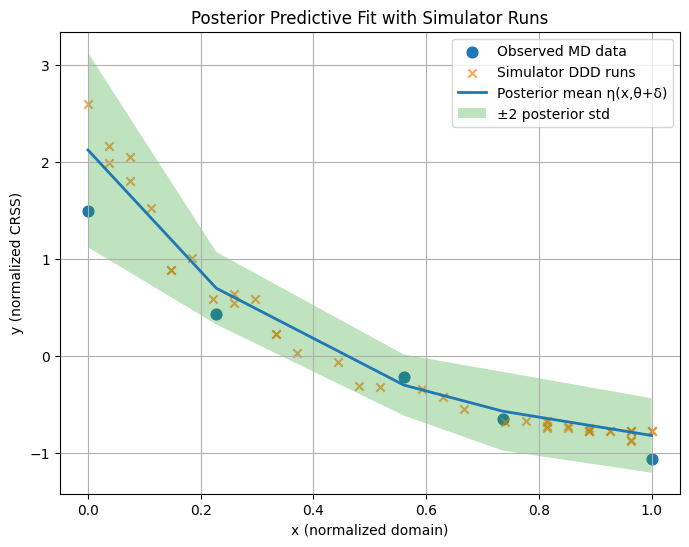

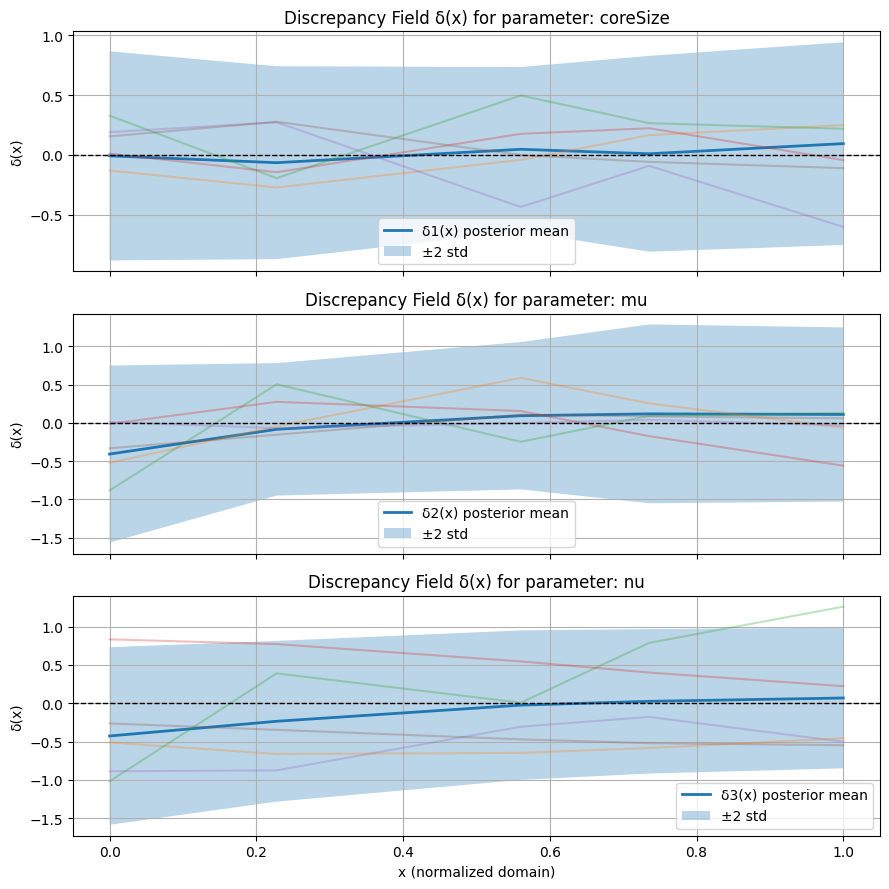

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Posterior predictive mean + uncertainty at obs locations
# ============================================================

No = len(x_obs)
Nmcmc = delta_chain.shape[0]
dtheta = delta_chain.shape[1]

Nsamp = 200
idx = np.random.choice(Nmcmc, Nsamp, replace=False)

y_preds = np.zeros((Nsamp, No))

for s_i, s in enumerate(idx):

    for i in range(No):

        delta_s = delta_chain[s, :, i]
        theta_star = theta_fixed + delta_s

        m_i, s2_i = eta_predict(x_obs[i], theta_star, gp_eta)

        # Draw one posterior predictive sample from emulator
        y_preds[s_i, i] = np.random.normal(m_i, np.sqrt(s2_i))


# Posterior mean and variance
y_post_mean = y_preds.mean(axis=0)
y_post_std  = y_preds.std(axis=0)


# ============================================================
# 2. Plot: Observations + Simulator + Posterior Fit
# ============================================================

plt.figure(figsize=(8,6))

# Observations
plt.scatter(
    x_obs, y_obs,
    label="Observed MD data",
    marker="o",
    s=60
)

# Simulator evaluations
plt.scatter(
    x_sim, y_sim,
    label="Simulator DDD runs",
    marker="x",
    alpha=0.7
)

# Posterior mean prediction
plt.plot(
    x_obs,
    y_post_mean,
    label="Posterior mean η(x,θ+δ)",
    linewidth=2
)

# Uncertainty band
plt.fill_between(
    x_obs.ravel(),
    y_post_mean - 2*y_post_std,
    y_post_mean + 2*y_post_std,
    alpha=0.3,
    label="±2 posterior std"
)

plt.title("Posterior Predictive Fit with Simulator Runs")
plt.xlabel("x (normalized domain)")
plt.ylabel("y (normalized CRSS)")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 3. Delta GP diagnostics: mean + band across x
# ============================================================

# Sort x for smooth plotting
x_sorted_idx = np.argsort(x_obs.ravel())
x_sorted = x_obs.ravel()[x_sorted_idx]

# Delta posterior mean/std at each x
delta_mean = delta_chain.mean(axis=0)   # shape (dtheta, No)
delta_std  = delta_chain.std(axis=0)

# ============================================================
# 4. Subplots: One delta_k(x) per calibration parameter
# ============================================================

fig, axes = plt.subplots(
    dtheta, 1,
    figsize=(9, 3*dtheta),
    sharex=True
)

if dtheta == 1:
    axes = [axes]

param_names = ["coreSize", "mu", "nu"]  # customize if needed

for k in range(dtheta):

    ax = axes[k]

    mean_k = delta_mean[k, x_sorted_idx]
    std_k  = delta_std[k, x_sorted_idx]

    # Posterior mean
    ax.plot(
        x_sorted,
        mean_k,
        label=f"δ{k+1}(x) posterior mean",
        linewidth=2
    )

    # Credible band
    ax.fill_between(
        x_sorted,
        mean_k - 2*std_k,
        mean_k + 2*std_k,
        alpha=0.3,
        label="±2 std"
    )

    # Overlay a few sample trajectories
    for j in range(5):
        s = np.random.choice(Nmcmc)
        sample_k = delta_chain[s, k, x_sorted_idx]
        ax.plot(x_sorted, sample_k, alpha=0.3)

    ax.axhline(0, color="black", linestyle="--", linewidth=1)

    name = param_names[k] if k < len(param_names) else f"theta{k}"
    ax.set_title(f"Discrepancy Field δ(x) for parameter: {name}")
    ax.set_ylabel("δ(x)")
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel("x (normalized domain)")

plt.tight_layout()
plt.show()


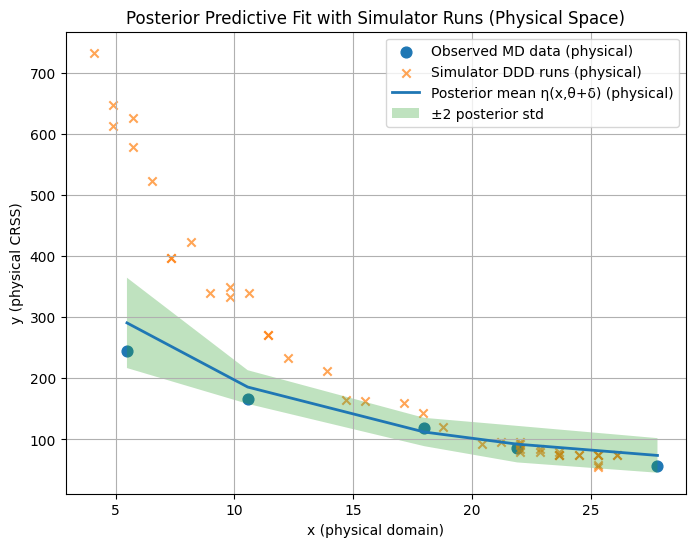

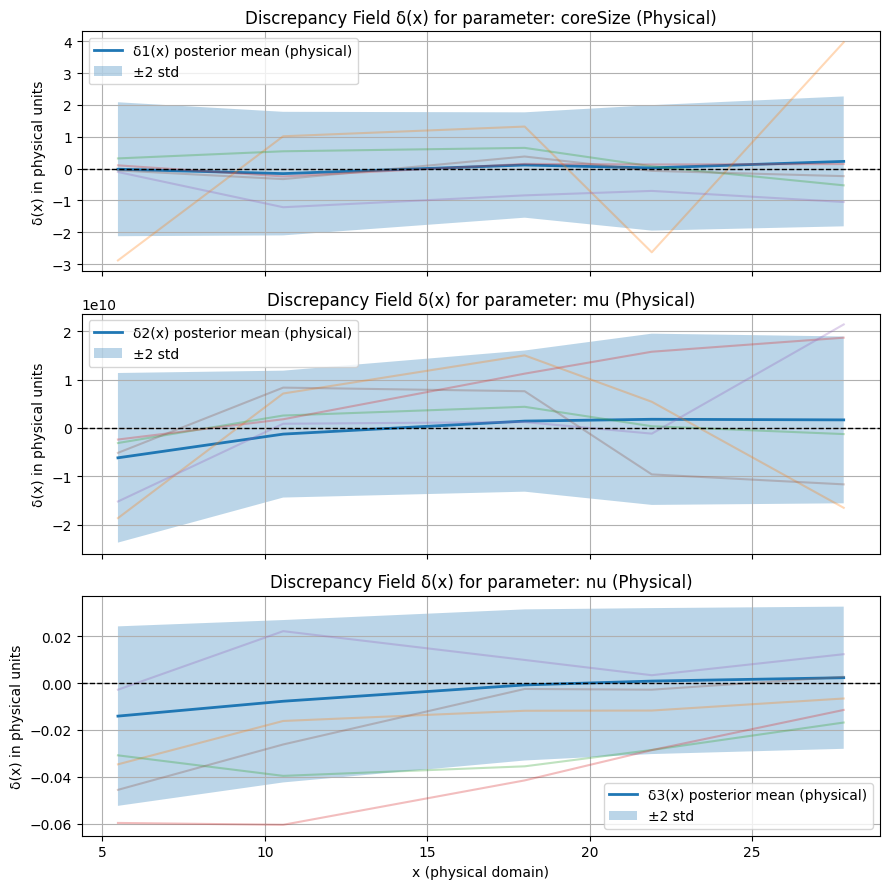

In [21]:
# ============================================================
# Convert back to physical space and replicate plots
# ============================================================

# ----- helpers for inverse transforms -----
# x normalization
x_obs_col = "x_dipoleSeparation_MD"
x_sim_col = "x_dipoleSeparation_DDD"

x_obs_min = obs_data[x_obs_col].min()
x_obs_max = obs_data[x_obs_col].max()

x_sim_min = model_data[x_sim_col].min()
x_sim_max = model_data[x_sim_col].max()

x_obs_phys = x_obs * (x_obs_max - x_obs_min) + x_obs_min
x_sim_phys = x_sim * (x_sim_max - x_sim_min) + x_sim_min

# y normalization
y_obs_col = "xi_crss_MD"
y_sim_col = "y_crss_DDD"

y_obs_mean = obs_data[y_obs_col].mean()
y_obs_std = obs_data[y_obs_col].std()

y_sim_mean = model_data[y_sim_col].mean()
y_sim_std = model_data[y_sim_col].std()

y_obs_phys = y_obs * y_obs_std + y_obs_mean
y_sim_phys = y_sim * y_sim_std + y_sim_mean

# denormalize posterior predictive (use obs scale to compare with obs)
y_post_mean_phys = y_post_mean * y_obs_std + y_obs_mean
y_post_std_phys = y_post_std * y_obs_std

# ----- delta: map to physical theta scale -----
theta_cols = ["theta_coreSize", "theta_mu", "theta_nu"]
theta_min = model_data[theta_cols].min().values
theta_max = model_data[theta_cols].max().values
theta_range = theta_max - theta_min

delta_chain_phys = delta_chain * theta_range[:, None]

# Sort x for smooth plotting (physical)
x_sorted_idx = np.argsort(x_obs_phys.ravel())
x_sorted_phys = x_obs_phys.ravel()[x_sorted_idx]

delta_mean_phys = delta_chain_phys.mean(axis=0)
delta_std_phys = delta_chain_phys.std(axis=0)

# ============================================================
# Plot: Observations + Simulator + Posterior Fit (physical)
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    x_obs_phys, y_obs_phys,
    label="Observed MD data (physical)",
    marker="o",
    s=60
)

plt.scatter(
    x_sim_phys, y_sim_phys,
    label="Simulator DDD runs (physical)",
    marker="x",
    alpha=0.7
)

plt.plot(
    x_obs_phys,
    y_post_mean_phys,
    label="Posterior mean η(x,θ+δ) (physical)",
    linewidth=2
)

plt.fill_between(
    x_obs_phys.ravel(),
    y_post_mean_phys - 2 * y_post_std_phys,
    y_post_mean_phys + 2 * y_post_std_phys,
    alpha=0.3,
    label="±2 posterior std"
)

plt.title("Posterior Predictive Fit with Simulator Runs (Physical Space)")
plt.xlabel("x (physical domain)")
plt.ylabel("y (physical CRSS)")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# Delta GP diagnostics in physical theta units
# ============================================================

fig, axes = plt.subplots(
    dtheta, 1,
    figsize=(9, 3*dtheta),
    sharex=True
)

if dtheta == 1:
    axes = [axes]

param_names = ["coreSize", "mu", "nu"]

for k in range(dtheta):
    ax = axes[k]

    mean_k = delta_mean_phys[k, x_sorted_idx]
    std_k = delta_std_phys[k, x_sorted_idx]

    ax.plot(
        x_sorted_phys,
        mean_k,
        label=f"δ{k+1}(x) posterior mean (physical)",
        linewidth=2
    )

    ax.fill_between(
        x_sorted_phys,
        mean_k - 2 * std_k,
        mean_k + 2 * std_k,
        alpha=0.3,
        label="±2 std"
    )

    for j in range(5):
        s = np.random.choice(Nmcmc)
        sample_k = delta_chain_phys[s, k, x_sorted_idx]
        ax.plot(x_sorted_phys, sample_k, alpha=0.3)

    ax.axhline(0, color="black", linestyle="--", linewidth=1)

    name = param_names[k] if k < len(param_names) else f"theta{k}"
    ax.set_title(f"Discrepancy Field δ(x) for parameter: {name} (Physical)")
    ax.set_ylabel("δ(x) in physical units")
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel("x (physical domain)")
plt.tight_layout()
plt.show()